# Multi-Fidelity Autoencoder

This notebook studies the reconstruction performance of the multi-fidelity autoencoder on the synthetic benchmark defined previously. The goal is to assess how well the model compresses and reconstructs low-fidelity and high-fidelity states, and how its performance changes with different training configurations and amounts of data.

The autoencoder is built around a shared latent representation. In the current formulation:
- low-fidelity and high-fidelity snapshots are passed through fidelity-specific input modules,
- then mapped into a common latent space,
- and finally decoded through fidelity-specific output modules.

Schematically, the model has the form
$$
x^{(f)} \xrightarrow{\;\mathcal E^{(f)}\;} z \xrightarrow{\;\mathcal D^{(f)}\;} \hat{x}^{(f)},
\qquad f \in \{\mathrm{LF},\mathrm{HF}\},
$$
where:
- $x^{(f)}$ is the input state at fidelity $f$,
- $\mathcal E^{(f)}$ is the encoder for fidelity $f$,
- $z$ is the shared latent representation,
- $\mathcal D^{(f)}$ is the decoder for fidelity $f$,
- $\hat{x}^{(f)}$ is the reconstructed state.

The training procedure can combine different loss terms.

A standard reconstruction term is
$$
\mathcal L_{\mathrm{rec}}^{(f)}
=
\frac{1}{N_f}
\sum_{i=1}^{N_f}
\left\|
x_i^{(f)} - \hat{x}_i^{(f)}
\right\|^2,
\qquad f \in \{\mathrm{LF},\mathrm{HF}\}.
$$

For paired low- and high-fidelity states, a shared-latent alignment term can also be introduced:
$$
\mathcal L_{\mathrm{align}}
=
\frac{1}{N_{\mathrm{MF}}}
\sum_{i=1}^{N_{\mathrm{MF}}}
\left\|
z_i^{(\mathrm{LF})} - z_i^{(\mathrm{HF})}
\right\|^2.
$$

If latent dynamics regularization is used, one may also include a SINDy residual term of the form
$$
\mathcal L_{\mathrm{SINDy}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left\|
\dot z_i - \Theta(z_i)\,\Xi
\right\|^2,
$$
where $\Theta(z)$ is the chosen library of candidate functions and $\Xi$ is the matrix of SINDy coefficients.

A typical total objective is therefore
$$
\mathcal L
=
\lambda_{\mathrm{LF}} \mathcal L_{\mathrm{rec}}^{(\mathrm{LF})}
+
\lambda_{\mathrm{HF}} \mathcal L_{\mathrm{rec}}^{(\mathrm{HF})}
+
\lambda_{\mathrm{align}} \mathcal L_{\mathrm{align}}
+
\lambda_{\mathrm{SINDy}} \mathcal L_{\mathrm{SINDy}}.
$$

In this notebook, we use a train/validation split, emphasize high-fidelity reconstruction slightly more strongly than low-fidelity reconstruction, and inspect both reconstructions and learned latent trajectories.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from mfl_rom.benchmarks.synthetic.spiral_ode import (
    generate_mf_trajectory,
    generate_trajectory,
    sample_ic,
)
from mfl_rom.compression.training import (
    BatchSizes,
    extract_shared_latent,
    fit,
    paired_common_time_grid,
    resample_state_sequence,
    sindy_residual_term,
    snapshot_reconstruction_term,
    state_alignment_term,
)
from mfl_rom.data import TrainingTrajectoryDataset

torch.set_default_dtype(torch.float32)

rng = np.random.default_rng(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: cpu


## Dataset

We build a small synthetic training and validation dataset. The paired multi-fidelity samples provide both LF and HF trajectories, while the extra single-fidelity pool is used only for LF. This keeps the notebook simple while still exercising the full multifidelity training pipeline.


In [2]:
def split_train_val(items, n_val):
    if n_val == 0:
        return items, []
    return items[:-n_val], items[-n_val:]


n_mf_total = 32
n_lf_total = 96

n_mf_val = 4
n_lf_val = 4

lf_time = np.linspace(0.0, 10.0, 100)
hf_time = np.linspace(0.0, 10.0, 1000)

mf_all = [
    generate_mf_trajectory(
        ic=sample_ic(rng=rng),
        lf_time=lf_time,
        hf_time=hf_time,
        rng=rng,
    )
    for _ in range(n_mf_total)
]

lf_all = [
    generate_trajectory(
        ic=sample_ic(rng=rng),
        time=lf_time,
        fidelity="LF",
        rng=rng,
    )
    for _ in range(n_lf_total)
]

mf_train, mf_val = split_train_val(mf_all, n_mf_val)
lf_train, lf_val = split_train_val(lf_all, n_lf_val)

train_dataset = TrainingTrajectoryDataset(
    mf_samples=mf_train,
    lf_samples=lf_train,
    hf_samples=[],
)

val_dataset = TrainingTrajectoryDataset(
    mf_samples=mf_val,
    lf_samples=lf_val,
    hf_samples=[],
)

example_mf = train_dataset.mf_samples[0]

print(f"Train MF samples: {len(train_dataset.mf_samples)}")
print(f"Train LF-only samples: {len(train_dataset.lf_samples)}")
print(f"Train HF-only samples: {len(train_dataset.hf_samples)}")
print()
print(f"Val MF samples: {len(val_dataset.mf_samples)}")
print(f"Val LF-only samples: {len(val_dataset.lf_samples)}")
print(f"Val HF-only samples: {len(val_dataset.hf_samples)}")
print()
print("LF paired shape:", example_mf.lf_trajectory.states.shape)
print("HF paired shape:", example_mf.hf_trajectory.states.shape)


Train MF samples: 28
Train LF-only samples: 92
Train HF-only samples: 0

Val MF samples: 4
Val LF-only samples: 4
Val HF-only samples: 0

LF paired shape: (100, 16, 16)
HF paired shape: (1000, 64, 64)


## Inspection

We first inspect one paired sample from the training set to confirm that the LF and HF observations are coherent and that the expected resolution gap is visible.


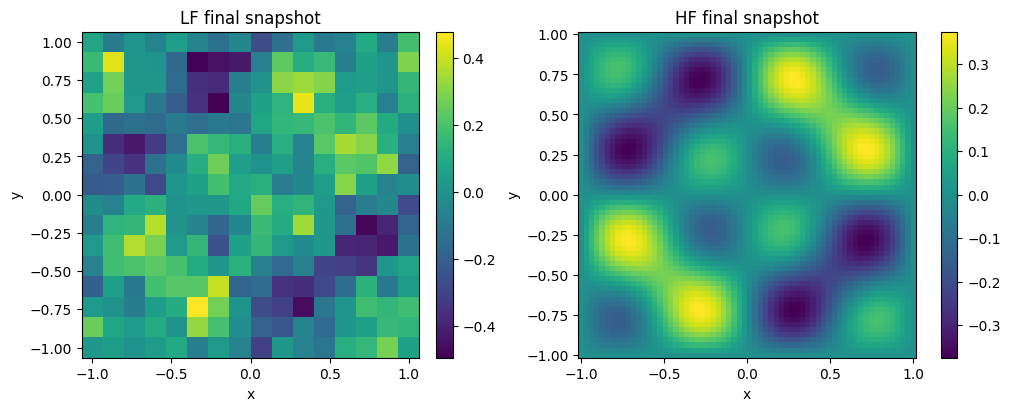

In [3]:
example_mf = train_dataset.mf_samples[0]

lf_snapshot = example_mf.lf_trajectory.states[-1]
hf_snapshot = example_mf.hf_trajectory.states[-1]

x_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[0])
y_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[1])
x_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[0])
y_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[1])

X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")
X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

pcm0 = ax[0].pcolormesh(X_lf, Y_lf, lf_snapshot, shading="auto")
ax[0].set_title("LF final snapshot")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(pcm0, ax=ax[0])

pcm1 = ax[1].pcolormesh(X_hf, Y_hf, hf_snapshot, shading="auto")
ax[1].set_title("HF final snapshot")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
fig.colorbar(pcm1, ax=ax[1])

plt.show()


## Autoencoder

Here we construct a simple shared-latent autoencoder for the synthetic multi-fidelity dataset.

The model takes as input a snapshot $x^{(f)}$ at fidelity $f \in \{\mathrm{LF}, \mathrm{HF}\}$, encodes it into a common latent representation $z$, and reconstructs it back to the same fidelity:
$$
x^{(f)} \xrightarrow{\;\mathcal E^{(f)}\;} z \xrightarrow{\;\mathcal D^{(f)}\;} \hat{x}^{(f)}.
$$

The implementation is modular. The autoencoder is assembled from:
- fidelity-specific encoder stems,
- a shared encoder trunk,
- a latent projection,
- a latent expansion,
- a shared decoder trunk,
- fidelity-specific decoder heads.

In this notebook we use a simple fully connected architecture:
- each input field is flattened,
- mapped to a common hidden dimension,
- compressed into a low-dimensional latent space,
- and then reconstructed back to the original LF or HF field shape.

This is intentionally a minimal model. Its role is not to be the final architecture, but to provide a clean first test of:
- the shared-latent autoencoder interface,
- the multi-fidelity training utilities,
- and the reconstruction/alignment pipeline on the synthetic benchmark.


In [4]:
import torch.nn as nn

from mfl_rom.compression.shared import SharedLatentAutoencoder

lf_shape = example_mf.lf_trajectory.states.shape[1:]
hf_shape = example_mf.hf_trajectory.states.shape[1:]

lf_dim = int(np.prod(lf_shape))
hf_dim = int(np.prod(hf_shape))

stem_dim = 128
trunk_dim = 64
latent_dim = 8

model = SharedLatentAutoencoder(
    encoder_stems={
        "LF": nn.Sequential(
            nn.Flatten(),
            nn.Linear(lf_dim, stem_dim),
            nn.ReLU(),
        ),
        "HF": nn.Sequential(
            nn.Flatten(),
            nn.Linear(hf_dim, stem_dim),
            nn.ReLU(),
        ),
    },
    shared_encoder=nn.Sequential(
        nn.Linear(stem_dim, trunk_dim),
        nn.ReLU(),
    ),
    to_latent=nn.Linear(trunk_dim, latent_dim),
    from_latent=nn.Linear(latent_dim, trunk_dim),
    shared_decoder=nn.Sequential(
        nn.Linear(trunk_dim, stem_dim),
        nn.ReLU(),
    ),
    decoder_heads={
        "LF": nn.Sequential(
            nn.Linear(stem_dim, lf_dim),
            nn.Unflatten(1, lf_shape),
        ),
        "HF": nn.Sequential(
            nn.Linear(stem_dim, hf_dim),
            nn.Unflatten(1, hf_shape),
        ),
    },
    latent_dim=latent_dim,
).to(device)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Trainable parameters: {num_parameters:,}")


SharedLatentAutoencoder(
  (encoder_stems): ModuleDict(
    (LF): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=256, out_features=128, bias=True)
      (2): ReLU()
    )
    (HF): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=4096, out_features=128, bias=True)
      (2): ReLU()
    )
  )
  (shared_encoder): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
  )
  (to_latent): Linear(in_features=64, out_features=8, bias=True)
  (from_latent): Linear(in_features=8, out_features=64, bias=True)
  (shared_decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder_heads): ModuleDict(
    (LF): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): Unflatten(dim=1, unflattened_size=(16, 16))
    )
    (HF): Sequential(
      (0): Linear(in_features=128, out_features=4096, bias=True)
      (1

## Training Setup

The training objective combines four SGD-compatible terms:
- LF reconstruction on independent LF snapshots,
- HF reconstruction on independent HF snapshots,
- paired state alignment in the shared latent space,
- a shared SINDy residual term on paired temporal transitions.

In this first experiment, HF reconstruction is weighted more strongly than LF reconstruction, since the main target of interest is the high-fidelity representation.


In [5]:
loss_weights = {
    "lf_reconstruction": 0.01,
    "hf_reconstruction": 1.0,
    "state_alignment": 0.1,
    "sindy_residual": 0.001,
}

from math import comb

def sindy_library(
    z: torch.Tensor,
    degree: int = 3,
    include_bias: bool = False,
) -> torch.Tensor:
    terms = []

    if include_bias:
        terms.append(torch.ones((z.shape[0], 1), device=z.device, dtype=z.dtype))

    latent_dim = z.shape[1]

    if degree >= 1:
        terms.extend(z[:, i:i+1] for i in range(latent_dim))

    if degree >= 2:
        terms.extend(
            z[:, i:i+1] * z[:, j:j+1]
            for i in range(latent_dim)
            for j in range(i, latent_dim)
        )

    if degree >= 3:
        terms.extend(
            z[:, i:i+1] * z[:, j:j+1] * z[:, k:k+1]
            for i in range(latent_dim)
            for j in range(i, latent_dim)
            for k in range(j, latent_dim)
        )

    return torch.cat(terms, dim=1)


def num_polynomial_library_terms(
    latent_dim: int,
    degree: int,
    include_bias: bool = True,
) -> int:
    num_terms = comb(latent_dim + degree, degree)
    if not include_bias:
        num_terms -= 1
    return num_terms

num_library_terms = num_polynomial_library_terms(
    latent_dim=latent_dim,
    degree=3,
    include_bias=False,
)

coefficients = nn.Parameter(
    1.0e-3 * torch.randn(num_library_terms, latent_dim, device=device)
)

optimizer = torch.optim.Adam(
    list(model.parameters()) + [coefficients],
    lr=1.0e-4,
)

batch_sizes = BatchSizes(
    lf=64,
    hf=64,
    mf_state=64,
    mf_sindy=64,
)


def loss_fn(model, batch_kind, batch, device):
    if batch_kind == "lf":
        rec = snapshot_reconstruction_term(model, batch, "LF", device)
        loss = loss_weights["lf_reconstruction"] * rec
        return loss, {
            "loss": float(loss.detach().cpu()),
            "reconstruction": float(rec.detach().cpu()),
        }

    if batch_kind == "hf":
        rec = snapshot_reconstruction_term(model, batch, "HF", device)
        loss = loss_weights["hf_reconstruction"] * rec
        return loss, {
            "loss": float(loss.detach().cpu()),
            "reconstruction": float(rec.detach().cpu()),
        }

    if batch_kind == "mf_state":
        align = state_alignment_term(model, batch, device)
        loss = loss_weights["state_alignment"] * align
        return loss, {
            "loss": float(loss.detach().cpu()),
            "state_alignment": float(align.detach().cpu()),
        }

    if batch_kind == "mf_sindy":
        sindy = sindy_residual_term(
            model=model,
            batch=batch,
            device=device,
            coefficients=coefficients,
            library_fn=sindy_library,
        )
        loss = loss_weights["sindy_residual"] * sindy
        return loss, {
            "loss": float(loss.detach().cpu()),
            "sindy_residual": float(sindy.detach().cpu()),
        }

    raise ValueError(f"Unknown batch kind: {batch_kind}")


print("Loss weights:", loss_weights)
print("Number of SINDy library terms:", num_library_terms)
print("Coefficient matrix shape:", tuple(coefficients.shape))
print("Batch sizes:", batch_sizes)


Loss weights: {'lf_reconstruction': 0.01, 'hf_reconstruction': 1.0, 'state_alignment': 0.1, 'sindy_residual': 0.001}
Number of SINDy library terms: 164
Coefficient matrix shape: (164, 8)
Batch sizes: BatchSizes(lf=64, hf=64, mf_state=64, mf_sindy=64)


## Training History

We train on the training split and monitor the same metrics on the validation split. This gives a quick view of whether the optimization is stable and whether the model is overfitting immediately.


  2%|▏         | 1/50 [00:20<16:58, 20.78s/it]

Epoch    1/50: train_lf/loss=3.2982e-04 | train_hf/loss=8.9677e-03 | train_mf_state/loss=9.4815e-04 | train_mf_sindy/loss=9.6414e-05 | val_lf/loss=2.0765e-04 | val_hf/loss=4.9189e-02 | val_mf_state/loss=4.6297e-03 | val_mf_sindy/loss=6.1207e-05


  4%|▍         | 2/50 [00:41<16:37, 20.77s/it]

Epoch    2/50: train_lf/loss=1.1735e-04 | train_hf/loss=6.0204e-04 | train_mf_state/loss=4.8312e-04 | train_mf_sindy/loss=3.5626e-05 | val_lf/loss=2.3710e-04 | val_hf/loss=4.3310e-02 | val_mf_state/loss=8.7751e-04 | val_mf_sindy/loss=2.8604e-05


  6%|▌         | 3/50 [01:02<16:17, 20.81s/it]

...

Epoch   48/50: train_lf/loss=9.9832e-05 | train_hf/loss=7.0709e-06 | train_mf_state/loss=3.5209e-06 | train_mf_sindy/loss=1.6110e-06 | val_lf/loss=1.0063e-04 | val_hf/loss=6.0062e-04 | val_mf_state/loss=4.1631e-05 | val_mf_sindy/loss=8.3283e-06


 98%|█████████▊| 49/50 [24:31<00:38, 38.99s/it]

Epoch   49/50: train_lf/loss=9.9841e-05 | train_hf/loss=7.1319e-06 | train_mf_state/loss=3.3394e-06 | train_mf_sindy/loss=1.5646e-06 | val_lf/loss=1.0077e-04 | val_hf/loss=4.7848e-04 | val_mf_state/loss=4.0788e-05 | val_mf_sindy/loss=8.2422e-06


100%|██████████| 50/50 [25:49<00:00, 31.00s/it]

Epoch   50/50: train_lf/loss=9.9844e-05 | train_hf/loss=5.5385e-06 | train_mf_state/loss=2.9948e-06 | train_mf_sindy/loss=1.4557e-06 | val_lf/loss=1.0067e-04 | val_hf/loss=5.2675e-04 | val_mf_state/loss=3.9263e-05 | val_mf_sindy/loss=8.1546e-06


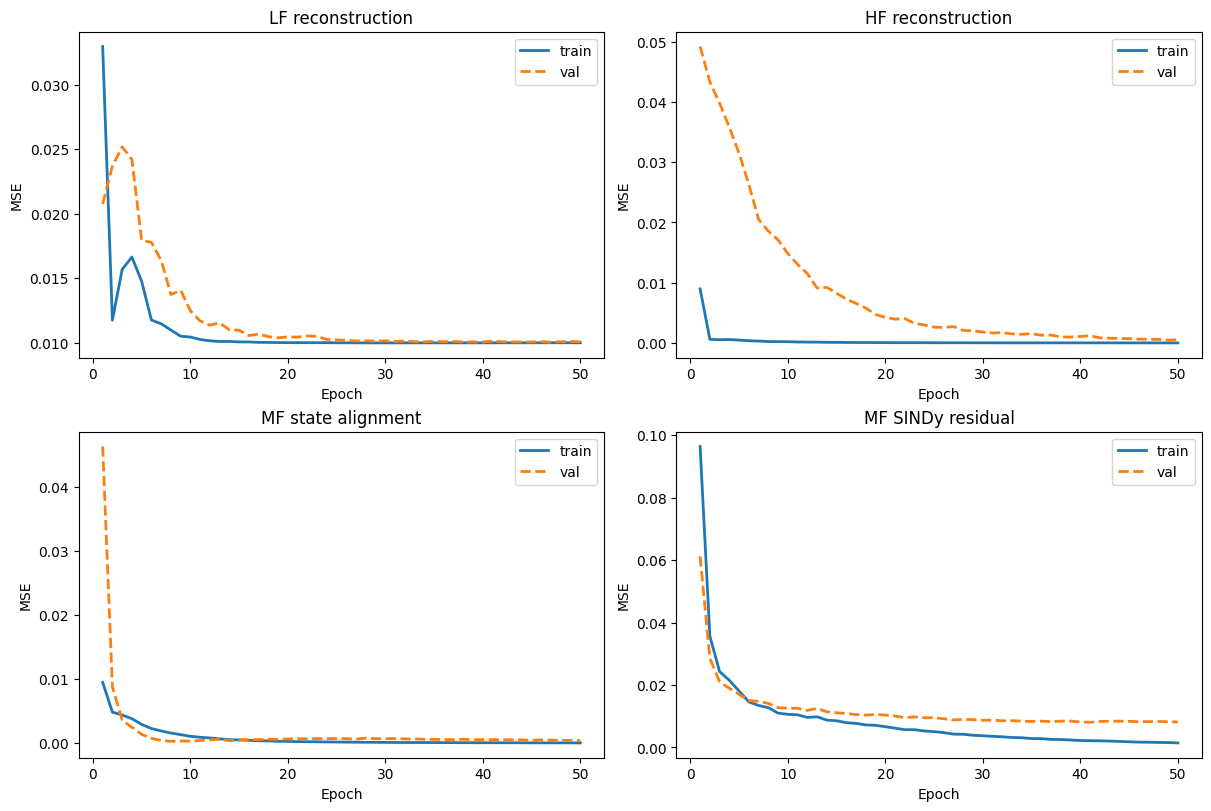

In [ ]:
num_epochs = 10 0

history = fit(
    model=model,
    dataset=train_dataset,
    optimizer=optimizer,
    device=device,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    batch_sizes=batch_sizes,
    val_dataset=val_dataset,
    rng=rng,
)


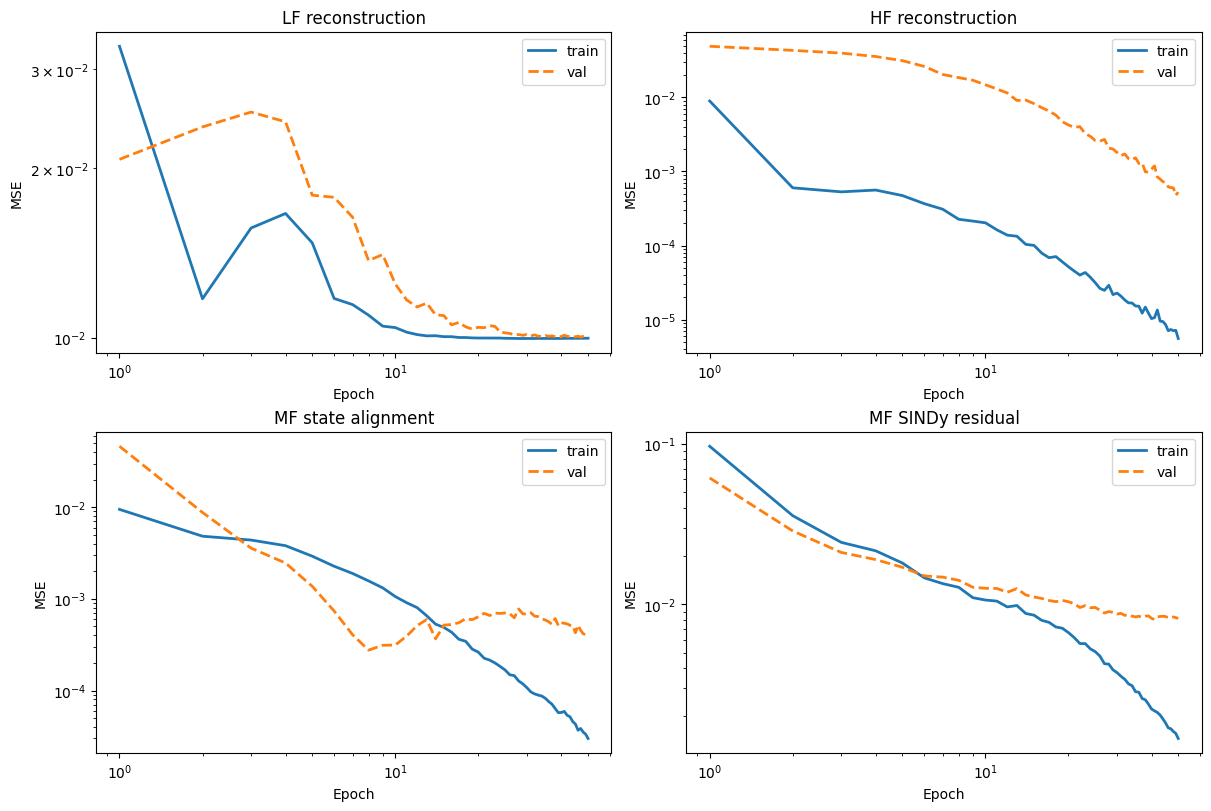

In [ ]:
epochs = np.arange(1, len(history) + 1)

metric_specs = [
    ("LF reconstruction", "lf/reconstruction"),
    ("HF reconstruction", "hf/reconstruction"),
    ("MF state alignment", "mf_state/state_alignment"),
    ("MF SINDy residual", "mf_sindy/sindy_residual"),
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for axis, (title, suffix) in zip(ax.ravel(), metric_specs, strict=True):
    train_values = [row.get(f"train_{suffix}", np.nan) for row in history]
    val_values = [row.get(f"val_{suffix}", np.nan) for row in history]

    axis.plot(epochs, train_values, linewidth=2, label="train")
    axis.plot(epochs, val_values, linewidth=2, linestyle="--", label="val")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE")
    axis.legend()
    axis.set_yscale('log')
    axis.set_xscale('log')

plt.show()


## Reconstructions

We now inspect one paired sample from the validation set and compare the true LF/HF states with their reconstructions. This is the simplest qualitative check that the autoencoder is learning a meaningful shared representation.


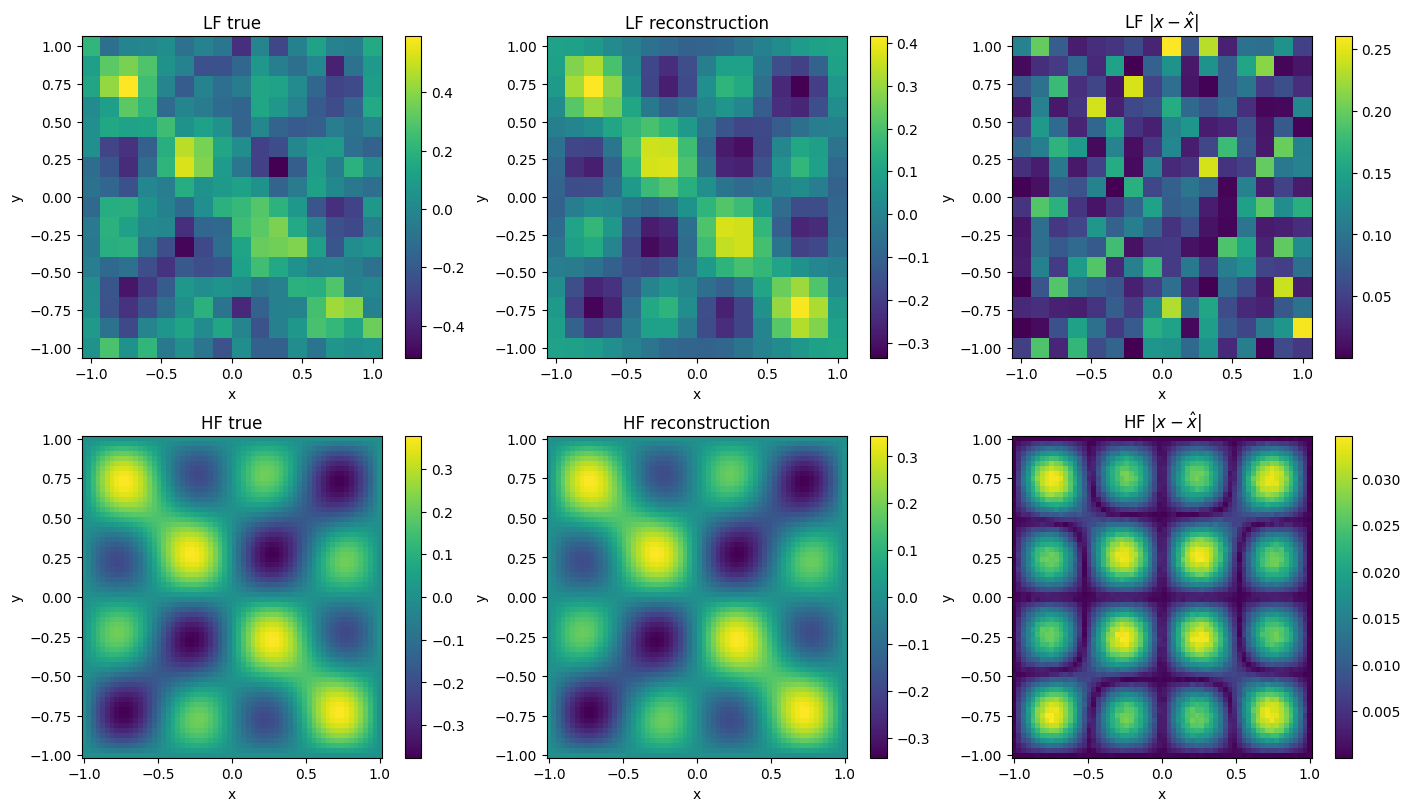

In [7]:
model.eval()

inspection_dataset = val_dataset if len(val_dataset.mf_samples) > 0 else train_dataset
example_mf = inspection_dataset.mf_samples[0]

lf_input = torch.as_tensor(
    example_mf.lf_trajectory.states,
    dtype=torch.float32,
    device=device,
)
hf_input = torch.as_tensor(
    example_mf.hf_trajectory.states,
    dtype=torch.float32,
    device=device,
)

with torch.no_grad():
    lf_reconstruction = model.reconstruct(lf_input, "LF").cpu().numpy()
    hf_reconstruction = model.reconstruct(hf_input, "HF").cpu().numpy()

lf_index = -1
hf_index = -1

lf_true = example_mf.lf_trajectory.states[lf_index]
lf_pred = lf_reconstruction[lf_index]
lf_error = np.abs(lf_true - lf_pred)

hf_true = example_mf.hf_trajectory.states[hf_index]
hf_pred = hf_reconstruction[hf_index]
hf_error = np.abs(hf_true - hf_pred)

x_lf = np.linspace(-1.0, 1.0, lf_true.shape[0])
y_lf = np.linspace(-1.0, 1.0, lf_true.shape[1])
x_hf = np.linspace(-1.0, 1.0, hf_true.shape[0])
y_hf = np.linspace(-1.0, 1.0, hf_true.shape[1])

X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")
X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")

fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

pcm = ax[0, 0].pcolormesh(X_lf, Y_lf, lf_true, shading="auto")
ax[0, 0].set_title("LF true")
fig.colorbar(pcm, ax=ax[0, 0])

pcm = ax[0, 1].pcolormesh(X_lf, Y_lf, lf_pred, shading="auto")
ax[0, 1].set_title("LF reconstruction")
fig.colorbar(pcm, ax=ax[0, 1])

pcm = ax[0, 2].pcolormesh(X_lf, Y_lf, lf_error, shading="auto")
ax[0, 2].set_title(r"LF $|x-\hat{x}|$")
fig.colorbar(pcm, ax=ax[0, 2])

pcm = ax[1, 0].pcolormesh(X_hf, Y_hf, hf_true, shading="auto")
ax[1, 0].set_title("HF true")
fig.colorbar(pcm, ax=ax[1, 0])

pcm = ax[1, 1].pcolormesh(X_hf, Y_hf, hf_pred, shading="auto")
ax[1, 1].set_title("HF reconstruction")
fig.colorbar(pcm, ax=ax[1, 1])

pcm = ax[1, 2].pcolormesh(X_hf, Y_hf, hf_error, shading="auto")
ax[1, 2].set_title(r"HF $|x-\hat{x}|$")
fig.colorbar(pcm, ax=ax[1, 2])

for axis in ax.ravel():
    axis.set_xlabel("x")
    axis.set_ylabel("y")

plt.show()


## Latent Trajectories

Finally, we resample one paired LF/HF sample onto a common physical time grid and inspect the encoded latent trajectories. This gives a direct view of how closely the shared latent space aligns the two fidelities.


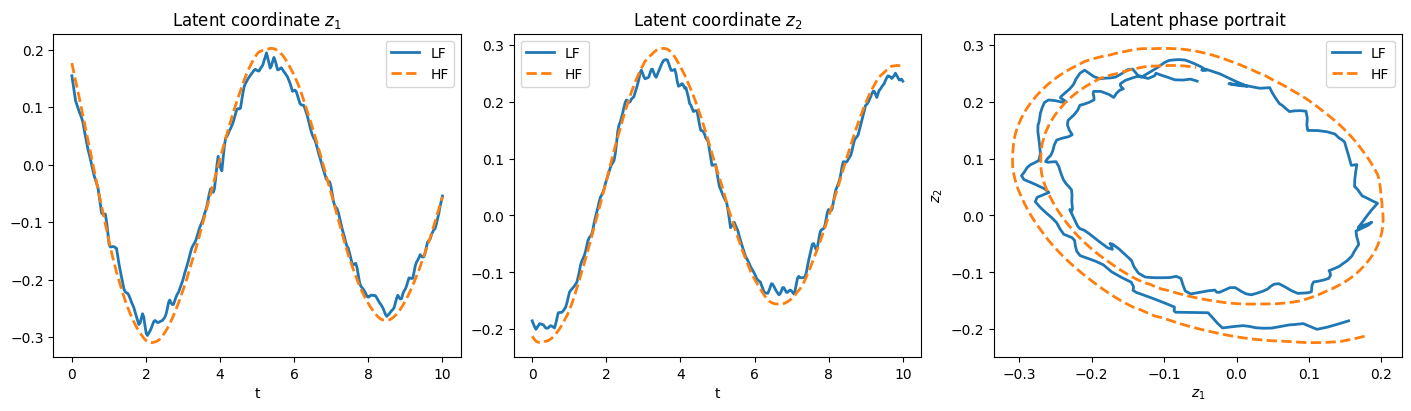

In [8]:
model.eval()

example_mf = inspection_dataset.mf_samples[0]
common_time = paired_common_time_grid(example_mf, target_steps=300)

lf_states = resample_state_sequence(
    example_mf.lf_trajectory.time,
    example_mf.lf_trajectory.states,
    common_time,
)
hf_states = resample_state_sequence(
    example_mf.hf_trajectory.time,
    example_mf.hf_trajectory.states,
    common_time,
)

lf_tensor = torch.as_tensor(lf_states, dtype=torch.float32, device=device)
hf_tensor = torch.as_tensor(hf_states, dtype=torch.float32, device=device)

with torch.no_grad():
    z_lf = extract_shared_latent(model, model.encode(lf_tensor, "LF")).cpu().numpy()
    z_hf = extract_shared_latent(model, model.encode(hf_tensor, "HF")).cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

ax[0].plot(common_time, z_lf[:, 0], linewidth=2, label="LF")
ax[0].plot(common_time, z_hf[:, 0], linewidth=2, linestyle="--", label="HF")
ax[0].set_title(r"Latent coordinate $z_1$")
ax[0].set_xlabel("t")
ax[0].legend()

ax[1].plot(common_time, z_lf[:, 1], linewidth=2, label="LF")
ax[1].plot(common_time, z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
ax[1].set_title(r"Latent coordinate $z_2$")
ax[1].set_xlabel("t")
ax[1].legend()

ax[2].plot(z_lf[:, 0], z_lf[:, 1], linewidth=2, label="LF")
ax[2].plot(z_hf[:, 0], z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
ax[2].set_title("Latent phase portrait")
ax[2].set_xlabel(r"$z_1$")
ax[2].set_ylabel(r"$z_2$")
ax[2].legend()

plt.show()
